This notebook serves a comparison purpose between few controll variables for future steps. The required setup is:

1. `density=0.25`
2. `shots=1000`
3. `seed=123` (following the previous IBM Fez experiment.)
4. `lengths = [2]+[4,10,20,50]`
5. Compare between `'edge_grab'`, `'matching'` and `'new'`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate  # <-- Add this import
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Define parameters for the simulated backend
num_qubits = 16
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle

shots = 1000 # 10000
lengths = [2]+[4,10,20,50] # ,100
num_samples = 20
 
cmap = CouplingMap.from_grid(4, 4, bidirectional=True)

In [3]:
# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])),  # Pauli Z gate
        "rz": Operator(
            [
                [np.cos(rz_angle / 2), -1j * np.sin(rz_angle / 2)],
                [-1j * np.sin(rz_angle / 2), np.cos(rz_angle / 2)],
            ]
        ),  # RZ(π/2)
        "cx": Operator(
            np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
        ),  # CNOT gate
    },
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

In [4]:
# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED
)

In [5]:
# Set up the experiment 01 ('edge_grab'+0.25) object
exp01 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25, # aim for 1.0 and 0.5 for mirror_qa_topo (0.25 from Fez)
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='edge_grab', # 'edge_grab', 'matching', 'new'
    seed=SEED
)

# Set run options
exp01.set_run_options(shots=shots)

rb_data_01 = exp01.run()
print(rb_data_01.job_ids)

for i in range(len(exp01._pairs)):
    print(f"Pairs from round {i}", exp01._pairs[i])

['2d7a1979-9666-4d40-9eba-4a5c6197295a']
Pairs from round 0 [(0, 4), (1, 5), (12, 8)]
Pairs from round 1 [(2, 6), (4, 8), (3, 7)]
Pairs from round 2 [(7, 11), (13, 9), (1, 2)]
Pairs from round 3 [(2, 1), (0, 4), (15, 14), (12, 8)]
Pairs from round 4 [(3, 7)]
Pairs from round 5 [(0, 1), (2, 3), (12, 8), (5, 4), (15, 14), (10, 6)]
Pairs from round 6 [(11, 7), (13, 12), (5, 1), (2, 6), (8, 9), (14, 15), (4, 0)]
Pairs from round 7 [(4, 8), (1, 5), (3, 2), (9, 13), (11, 15), (7, 6)]
Pairs from round 8 [(4, 5), (9, 13), (6, 2), (14, 15), (3, 7)]
Pairs from round 9 [(15, 11), (13, 14), (10, 6), (0, 1)]
Pairs from round 10 [(4, 8), (1, 5), (13, 9)]
Pairs from round 11 [(14, 10), (12, 8), (9, 13), (11, 15), (2, 6)]
Pairs from round 12 [(4, 5), (2, 3), (1, 0), (13, 9)]
Pairs from round 13 [(1, 2), (0, 4), (13, 12), (7, 3)]
Pairs from round 14 [(15, 14), (12, 13), (7, 11)]
Pairs from round 15 [(2, 3), (1, 5), (10, 9), (4, 8), (12, 13)]
Pairs from round 16 [(13, 12), (6, 10), (3, 7), (15, 11), (9,

In [6]:
# Set up the experiment 02 ('matching'+0.25) object
exp02 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.5, # aim for 1.0 and 0.5 for mirror_qa_topo (0.25 from Fez)
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='matching', # 'edge_grab', 'matching', 'new'
    seed=SEED
)

# Set run options
exp02.set_run_options(shots=shots)

rb_data_02 = exp02.run()
print(rb_data_02.job_ids)

for i in range(len(exp02._pairs)):
    print(f"Pairs from round {i}", exp02._pairs[i])

['9a44cf97-34bd-4dc0-a0d8-62dc07717ca9']
Pairs from round 0 [(4, 0), (10, 11), (5, 1), (13, 9), (7, 6), (8, 12), (3, 2), (14, 15)]
Pairs from round 1 [(10, 11), (2, 3), (6, 7), (13, 9), (4, 5), (8, 12), (1, 0), (14, 15)]
Pairs from round 2 [(13, 14), (1, 2), (0, 4), (3, 7), (11, 15), (5, 6), (8, 12), (10, 9)]
Pairs from round 3 [(9, 10), (6, 5), (2, 3), (4, 8), (13, 12), (1, 0), (7, 11), (14, 15)]
Pairs from round 4 [(9, 10), (13, 14), (6, 2), (4, 0), (3, 7), (5, 1), (11, 15), (8, 12)]
Pairs from round 5 [(0, 1), (10, 11), (5, 4), (12, 13), (2, 3), (6, 7), (9, 8), (14, 15)]
Pairs from round 6 [(9, 10), (13, 14), (0, 4), (1, 5), (2, 3), (7, 6), (11, 15), (8, 12)]
Pairs from round 7 [(10, 14), (5, 4), (12, 13), (2, 3), (6, 7), (8, 9), (11, 15), (1, 0)]
Pairs from round 8 [(9, 10), (0, 1), (8, 4), (6, 5), (12, 13), (2, 3), (7, 11), (14, 15)]
Pairs from round 9 [(0, 1), (8, 4), (12, 13), (2, 3), (5, 6), (10, 9), (7, 11), (14, 15)]
Pairs from round 10 [(0, 1), (11, 7), (8, 4), (6, 5), (12, 

In [7]:
lengths

[2, 4, 10, 20, 50]

In [8]:
# Set up the experiment 01 ('edge_grab'+0.25) object
exp03 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25, 
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='new', # 'edge_grab', 'matching', 'new'
    seed=SEED,
    # full_sampling=True
)

# Set run options
exp03.set_run_options(shots=shots)

rb_data_03 = exp03.run()
print(rb_data_03.job_ids)

# Print all available rounds, not a fixed range
for i in range(len(exp03._pairs)):
    print(f"Pairs from round {i}", exp03._pairs[i])

['a4359b7b-ff93-4945-b8f6-2e4a69667717']
Pairs from round 0 []
Pairs from round 1 []
Pairs from round 2 []
Pairs from round 3 []
Pairs from round 4 []
Pairs from round 5 []
Pairs from round 6 []
Pairs from round 7 []
Pairs from round 8 []
Pairs from round 9 []
Pairs from round 10 []
Pairs from round 11 []
Pairs from round 12 []
Pairs from round 13 []
Pairs from round 14 []
Pairs from round 15 []
Pairs from round 16 []
Pairs from round 17 []
Pairs from round 18 []
Pairs from round 19 []
Pairs from round 20 []
Pairs from round 21 []
Pairs from round 22 []
Pairs from round 23 []
Pairs from round 24 []
Pairs from round 25 []
Pairs from round 26 []
Pairs from round 27 []
Pairs from round 28 []
Pairs from round 29 []
Pairs from round 30 []
Pairs from round 31 []
Pairs from round 32 []
Pairs from round 33 []
Pairs from round 34 []
Pairs from round 35 []
Pairs from round 36 []
Pairs from round 37 []
Pairs from round 38 []
Pairs from round 39 []
Pairs from round 40 []
Pairs from round 41 []
Pai

In [9]:
# *** It's stuck here ***
exp03.analysis.set_options(analyzed_quantity="Effective Polarization")
# exp.analysis.set_options(analyzed_quantity='Mutual Information')

In [10]:
analysis = exp03.analysis.run(rb_data_03)

In [11]:
# job id: '4d59ce51-72cc-4f0e-99ed-c2ee2e907ffa' (from Tue 9 Feb 09:20)
print(rb_data_03)

---------------------------------------------------
Experiment: MirrorQA
Experiment ID: dd76d9c0-0d39-4bad-a1b2-e00376dd036e
Status: ExperimentStatus.RUNNING
Backend: AerSimulator('aer_simulator_stabilizer'
             noise_model=<NoiseModel on ['cx', 'z', 'x', 'h', 'id', 'y', 'rz']>)
Data: 0
Analysis Results: 0
Figures: 0
Artifacts: 0


In [12]:
analysis.figure(0)

ExperimentEntryNotFound: 'Figure index 0 out of range.'

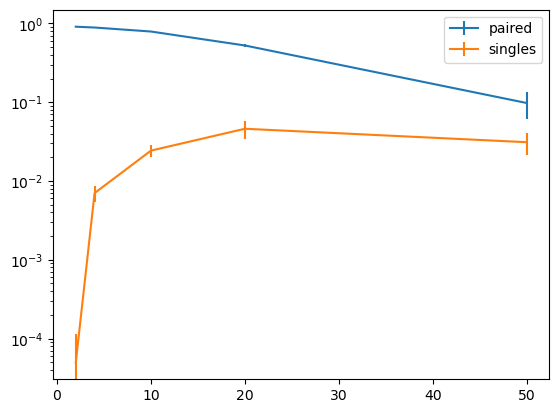

In [ ]:
qa = QuantumAwesomeness(exp03.backend.coupling_map)

mi = qa.mutual_info(rb_data_03.data())
mmi = qa.mean_mutual_info(rb_data_03.data(), exp03._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

Length   2: paired=0.9098, singles=0.000050, ratio=18326.3x
Length   4: paired=0.8885, singles=0.007017, ratio=126.6x
Length  10: paired=0.7904, singles=0.024308, ratio=32.5x
Length  20: paired=0.5257, singles=0.046051, ratio=11.4x
Length  50: paired=0.0978, singles=0.031090, ratio=3.1x


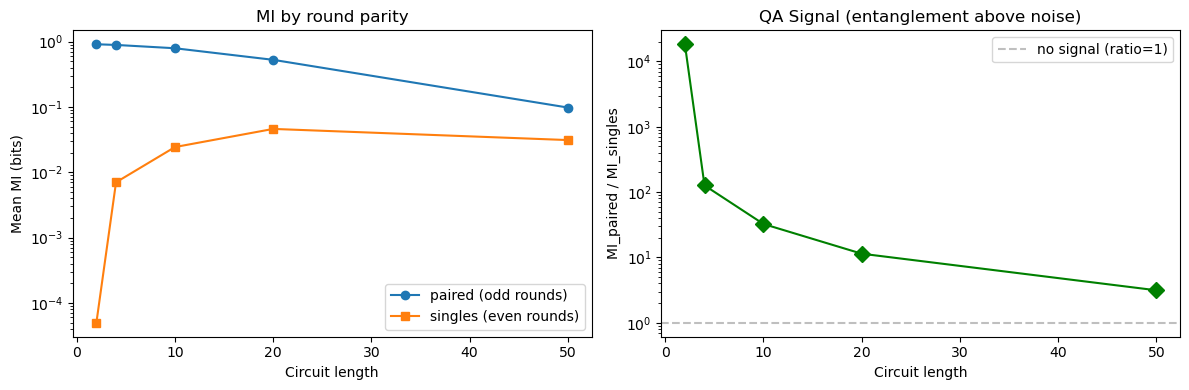

In [ ]:
# QA Signal: ratio of entangled MI to non-entangled MI per circuit length.
# This measures how much entanglement stands above the noise floor.
# A ratio >> 1 means the device creates genuine entanglement;
# the decay rate with circuit depth characterises device quality.

# Separate rounds by parity: odd rounds have 2q pairs, even rounds are 1q-only
paired_by_length = {L: [] for L in lengths}
singles_by_length = {L: [] for L in lengths}

for j in range(len(mmi["paired"])):
    L = lengths[j % num_lengths]
    if j % 2 == 1:  # odd round: entangling pairs present
        val = mmi["paired"][j]
        if not np.isnan(val):
            paired_by_length[L].append(val)
    else:  # even round: no entangling pairs
        val = mmi["singles"][j]
        if not np.isnan(val):
            singles_by_length[L].append(val)

paired_means = np.array([np.mean(paired_by_length[L]) if paired_by_length[L] else np.nan for L in lengths])
singles_means = np.array([np.mean(singles_by_length[L]) if singles_by_length[L] else np.nan for L in lengths])

# QA signal = ratio of paired MI to singles MI
qa_signal = paired_means / singles_means

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: paired vs singles MI (same as above, but with parity-separated data)
ax1.errorbar(lengths, paired_means, fmt='-o', label="paired (odd rounds)")
ax1.errorbar(lengths, singles_means, fmt='-s', label="singles (even rounds)")
ax1.set_xlabel("Circuit length")
ax1.set_ylabel("Mean MI (bits)")
ax1.set_yscale("log")
ax1.set_title("MI by round parity")
ax1.legend()

# Right: QA signal ratio
ax2.plot(lengths, qa_signal, '-D', color='green', markersize=8)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label="no signal (ratio=1)")
ax2.set_xlabel("Circuit length")
ax2.set_ylabel("MI_paired / MI_singles")
ax2.set_yscale("log")
ax2.set_title("QA Signal (entanglement above noise)")
ax2.legend()

plt.tight_layout()

# Print the numbers
for L, p, s, r in zip(lengths, paired_means, singles_means, qa_signal):
    print(f"Length {L:>3d}: paired={p:.4f}, singles={s:.6f}, ratio={r:.1f}x")